In [ ]:
!pip install imutils

In [ ]:
from imutils import paths
import os
import numpy as np
import random
import pandas as pd
from sklearn.model_selection import train_test_split

import cv2
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from scipy import ndimage as ndi
from skimage import morphology
import time

import keras,math
from keras.applications.inception_v3 import InceptionV3
from keras.layers import GlobalAveragePooling2D,BatchNormalization
from keras.layers import Dense,Dropout
from keras.models import Model

import tensorflow as tf
from tensorflow.keras.applications import DenseNet201
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.optimizers.schedules import ExponentialDecay
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import regularizers

import tensorflow as tf
from sklearn.metrics import mean_absolute_error,mean_squared_error
from sklearn import metrics

In [ ]:
!mkdir /tmp/prepared_data/

!mkdir /tmp/prepared_data/benign
!mkdir /tmp/prepared_data/PreB
!mkdir /tmp/prepared_data/ProB
!mkdir /tmp/prepared_data/EarlyPreB

!mkdir /tmp/prepared_test/

!mkdir /tmp/prepared_test/benign
!mkdir /tmp/prepared_test/PreB
!mkdir /tmp/prepared_test/ProB
!mkdir /tmp/prepared_test/EarlyPreB

In [ ]:
data_dir  = '/content/drive/MyDrive/ Acute Lymphoblastic Leukemia/Blood cell Cancer [ALL]'
data_list = sorted(list(paths.list_images(data_dir)))

random.seed(88)
random.shuffle(data_list)

train_list, test_list = train_test_split(data_list, train_size=0.90, shuffle=True, random_state=88)

print('number of testing list -:',len(test_list))
print('number of training list-:',len(train_list))

number of testing list -: 325
number of training list-: 2917


In [ ]:
print('Number of samples in dataset:',len(list(paths.list_images("/content/drive/MyDrive/ Acute Lymphoblastic Leukemia/Blood cell Cancer [ALL]"))),'\n')

print('Number of samples in each class:','\n')
print("#1 Benign ---------------:", len(list(paths.list_images("/content/drive/MyDrive/ Acute Lymphoblastic Leukemia/Blood cell Cancer [ALL]/Benign"))))
print("#2 Malignant[Early PreB] :", len(list(paths.list_images("/content/drive/MyDrive/ Acute Lymphoblastic Leukemia/Blood cell Cancer [ALL]/[Malignant] early Pre-B"))))
print("#3 Malignant[PreB] ------:", len(list(paths.list_images("/content/drive/MyDrive/ Acute Lymphoblastic Leukemia/Blood cell Cancer [ALL]/[Malignant] Pre-B"))))
print("#4 Malignant[ProB] ------:", len(list(paths.list_images("/content/drive/MyDrive/ Acute Lymphoblastic Leukemia/Blood cell Cancer [ALL]/[Malignant] Pro-B"))))

Number of samples in dataset: 3242 

Number of samples in each class: 

#1 Benign ---------------: 512
#2 Malignant[Early PreB] : 979
#3 Malignant[PreB] ------: 955
#4 Malignant[ProB] ------: 796


In [ ]:
p=0

for img in test_list[:]:

    i= cv2.imread(img)
    i= cv2.resize(i,(224,224))
    lable= img.split(os.path.sep)[6] # Corrected index from 4 to 6

    if (lable=="Benign"):
        b= ('/tmp/prepared_test/benign/'+lable+str(p)+'.png')
    elif (lable=="[Malignant] Pre-B"):
        b= ('/tmp/prepared_test/PreB/'+lable+str(p)+'.png')
    elif (lable=="[Malignant] Pro-B"):
        b= ('/tmp/prepared_test/ProB/'+lable+str(p)+'.png')
    elif (lable=="[Malignant] early Pre-B"):
        b= ('/tmp/prepared_test/EarlyPreB/'+lable+str(p)+'.png')
    else:
        # Fallback in case of unexpected label, to avoid NameError
        # You might want to log this or handle it differently based on requirements
        print(f"Warning: Unexpected label found: {lable}. Skipping image: {img}")
        continue # Skip to the next image if label is not recognized
    p+=1
    cv2.imwrite(b,i)

In [ ]:
p=0
tic = time.perf_counter()

for img in train_list[:]:

    i= cv2.imread(img)
    i= cv2.resize(i,(224,224))
    lable= img.split(os.path.sep)[-2] # Changed index to -2 to get the folder name

    # Save the original image
    if lable == "Benign":
        b = f"/tmp/prepared_data/benign/{'Benign'}{p}.png"
        cv2.imwrite(b,i)
        p+=1
    if lable == "[Malignant] Pre-B":
        b = f"/tmp/prepared_data/PreB/{'[Malignant] Pre-B'}{p}.png"
        cv2.imwrite(b,i)
        p+=1
    if lable == "[Malignant] Pro-B":
        b = f"/tmp/prepared_data/ProB/{'[Malignant] Pro-B'}{p}.png"
        cv2.imwrite(b,i)
        p+=1
    if lable == "[Malignant] early Pre-B":
        b = f"/tmp/prepared_data/EarlyPreB/{'[Malignant] early Pre-B'}{p}.png"
        cv2.imwrite(b,i)
        p+=1




 #-------- Segmentation ---------
    i= cv2.cvtColor(i, cv2.COLOR_BGR2RGB)
    i_lab = cv2.cvtColor(i, cv2.COLOR_RGB2LAB)        #RGB -> LAB
    l,a,b_channel = cv2.split(i_lab) # Renamed variable to avoid conflict
    i2 = a.reshape(a.shape[0]*a.shape[1],1)
    km = KMeans(n_clusters=7, random_state=0, n_init=10).fit(i2)
    p2s= km.cluster_centers_[km.labels_]
    ic= p2s.reshape(a.shape[0],a.shape[1])
    ic = ic.astype(np.uint8)
    r,t = cv2.threshold(ic,141,255 ,cv2.THRESH_BINARY) #Binary Thresholding
    fh = ndi.binary_fill_holes(t)                      #fill holes
    m1 = morphology.remove_small_objects(fh, 200)
    m2 = morphology.remove_small_holes(m1,250)
    m2 = m2.astype(np.uint8)
    out = cv2.bitwise_and(i, i, mask=m2)

    # Save the segmented image
    if lable == "Benign":
        b = f"/tmp/prepared_data/benign/{'Benign_segmented'}{p}.png" # Changed filename for segmented image
        out= cv2.cvtColor(out, cv2.COLOR_RGB2BGR)
        cv2.imwrite(b,out)
    if lable == "[Malignant] Pre-B":
        b = f"/tmp/prepared_data/PreB/{'[Malignant] Pre-B_segmented'}{p}.png" # Changed filename for segmented image
        out= cv2.cvtColor(out, cv2.COLOR_RGB2BGR)
        cv2.imwrite(b,out)
    if lable == "[Malignant] Pro-B":
        b = f"/tmp/prepared_data/ProB/{'[Malignant] Pro-B_segmented'}{p}.png" # Changed filename for segmented image
        out= cv2.cvtColor(out, cv2.COLOR_RGB2BGR)
        cv2.imwrite(b,out)
    if lable == "[Malignant] early Pre-B":
        b = f"/tmp/prepared_data/EarlyPreB/{'[Malignant] early Pre-B_segmented'}{p}.png" # Changed filename for segmented image
        out= cv2.cvtColor(out, cv2.COLOR_RGB2BGR)
        cv2.imwrite(b,out)



toc2 = time.perf_counter()
print(f"2917 samples processed in { ((toc2 - tic)/60) } minutes")

2917 samples processed in 53.428871221449995 minutes


In [ ]:
#------- train/valid Datafarame -------

prepared_data_path = '/tmp/prepared_data/'
prepared_data_list_filenames = (sorted(list(paths.list_images(prepared_data_path))))
random.shuffle(prepared_data_list_filenames)
prepared_data_list_labels = []

for line in prepared_data_list_filenames:
    prepared_data_list_labels.append(line.split(os.path.sep)[3])

I_series = pd.Series(prepared_data_list_filenames, name='filenames')
L_series = pd.Series(prepared_data_list_labels, name='labels')
df = pd.concat( [I_series, L_series], axis=1)

print('-- train/valid Datafarame --')

print(df.head())
#print number of each class:
a=df['labels'].value_counts()
a

-- train/valid Datafarame --
                                           filenames     labels
0  /tmp/prepared_data/EarlyPreB/[Malignant] early...  EarlyPreB
1            /tmp/prepared_data/benign/Benign390.png     benign
2  /tmp/prepared_data/ProB/[Malignant] Pro-B_segm...       ProB
3  /tmp/prepared_data/ProB/[Malignant] Pro-B1710.png       ProB
4  /tmp/prepared_data/EarlyPreB/[Malignant] early...  EarlyPreB


,count
labels,
EarlyPreB,1736
PreB,1724
ProB,1436
benign,938


In [ ]:
#------- test Datafarame ---------

prepared_data_path = '/tmp/prepared_test/'
prepared_data_list_filenames = (sorted(list(paths.list_images(prepared_data_path))))
random.shuffle(prepared_data_list_filenames)
prepared_data_list_labels = []

for line in prepared_data_list_filenames:
    prepared_data_list_labels.append(line.split(os.path.sep)[3])

I_series = pd.Series(prepared_data_list_filenames, name='filenames')
L_series = pd.Series(prepared_data_list_labels, name='labels')
test_df = pd.concat( [I_series, L_series], axis=1)

print('-- test Datafarame --')
print(test_df.head())
#print number of each class:
a=test_df['labels'].value_counts()
a


-- test Datafarame --
                                           filenames     labels
0   /tmp/prepared_test/PreB/[Malignant] Pre-B262.png       PreB
1            /tmp/prepared_test/benign/Benign107.png     benign
2   /tmp/prepared_test/PreB/[Malignant] Pre-B291.png       PreB
3  /tmp/prepared_test/EarlyPreB/[Malignant] early...  EarlyPreB
4   /tmp/prepared_test/ProB/[Malignant] Pro-B202.png       ProB


,count
labels,
EarlyPreB,111
PreB,93
ProB,78
benign,43


In [ ]:
SPLIT= 0.90

TRAIN_DF, VALID_DF = train_test_split(df, train_size=SPLIT, shuffle=True, random_state=88)

print('Train samples: ', len(TRAIN_DF))
print('Valid samples: ', len(VALID_DF))
print('Test samples : ', len(test_df))

Train samples:  5250
Valid samples:  584
Test samples :  325


In [ ]:
BATCH_SIZE= 32
IMG_SHAPE= (224, 224, 3)
IMG_SIZE= (224, 224)

gen = ImageDataGenerator(rescale=1./255,
                         vertical_flip=True,
                         horizontal_flip=True)
                         #rotation_range=10)

gen2 = ImageDataGenerator(rescale=1./255)

train_gen = gen.flow_from_dataframe(TRAIN_DF,
                                    x_col= 'filenames',
                                    y_col= 'labels',
                                    target_size= IMG_SIZE,
                                    class_mode= 'categorical',
                                    color_mode= 'rgb',
                                    shuffle= True,
                                    batch_size= BATCH_SIZE,
                                    seed=88
)

valid_gen= gen2.flow_from_dataframe(VALID_DF,
                                    x_col= 'filenames',
                                    y_col= 'labels',
                                    target_size= IMG_SIZE,
                                    class_mode= 'categorical',
                                    color_mode= 'rgb',
                                    shuffle= True,
                                    batch_size= BATCH_SIZE,
                                    seed=88
)
test_gen= gen2.flow_from_dataframe(test_df,
                                   x_col= 'filenames',
                                   y_col= 'labels',
                                   target_size= IMG_SIZE,
                                   class_mode= 'categorical',
                                   color_mode= 'rgb',
                                   shuffle= True,
                                   batch_size= 325,
                                   seed=88
)


STEPS= int( len(train_gen.labels)/BATCH_SIZE)
print(STEPS)

Found 5250 validated image filenames belonging to 4 classes.
Found 584 validated image filenames belonging to 4 classes.
Found 325 validated image filenames belonging to 4 classes.
164


In [ ]:
from keras.layers import Flatten, Dense, Dropout, GlobalAveragePooling2D, BatchNormalization


base_model= tf.keras.applications.mobilenet_v2.MobileNetV2(include_top=False,weights='imagenet',input_shape=(224,224,3))
#tf.keras.applications.MobileNetV3Small

x = Flatten()(base_model.output)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)
output = Dense(4, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=output)

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

model = Model(inputs=base_model.input, outputs=output)

In [ ]:
initial_learning_rate = 0.0001
lr_schedule = tf.keras.optimizers.schedules.ExponentialDecay(
    initial_learning_rate,
    decay_steps=40,
    decay_rate=0.96,
    staircase=False)


model.compile(loss='categorical_crossentropy',optimizer=Adam(learning_rate=lr_schedule, beta_1=0.9, beta_2=0.999, epsilon=1e-08), #optimizer=Adam(learning_rate=0.00001,decay = 10e-5),
              metrics=['accuracy'])
             # option = run_opts)

In [ ]:
history =         model.fit(x=train_gen,
                            epochs=15,
                            validation_data=valid_gen,
                            steps_per_epoch=None
                   )

Epoch 1/15
165/165 ━━━━━━━━━━━━━━━━━━━━ 100s 308ms/step - accuracy: 0.8881 - loss: 0.3151 - val_accuracy: 0.3253 - val_loss: 8.5986
Epoch 2/15
165/165 ━━━━━━━━━━━━━━━━━━━━ 20s 123ms/step - accuracy: 0.9210 - loss: 0.2149 - val_accuracy: 0.4127 - val_loss: 5.2255
Epoch 3/15
165/165 ━━━━━━━━━━━━━━━━━━━━ 20s 119ms/step - accuracy: 0.9404 - loss: 0.1624 - val_accuracy: 0.4812 - val_loss: 3.7558
Epoch 4/15
165/165 ━━━━━━━━━━━━━━━━━━━━ 19s 116ms/step - accuracy: 0.9452 - loss: 0.1552 - val_accuracy: 0.5634 - val_loss: 2.7909
Epoch 5/15
165/165 ━━━━━━━━━━━━━━━━━━━━ 20s 120ms/step - accuracy: 0.9481 - loss: 0.1428 - val_accuracy: 0.7021 - val_loss: 1.4866
Epoch 6/15
165/165 ━━━━━━━━━━━━━━━━━━━━ 20s 122ms/step - accuracy: 0.9511 - loss: 0.1642 - val_accuracy: 0.7260 - val_loss: 1.1005
Epoch 7/15
165/165 ━━━━━━━━━━━━━━━━━━━━ 21s 129ms/step - accuracy: 0.9511 - loss: 0.1501 - val_accuracy: 0.7791 - val_loss: 0.7474
Epoch 8/15
165/165 ━━━━━━━━━━━━━━━━━━━━ 19s 116ms/step - accuracy: 0.9548 - loss: 

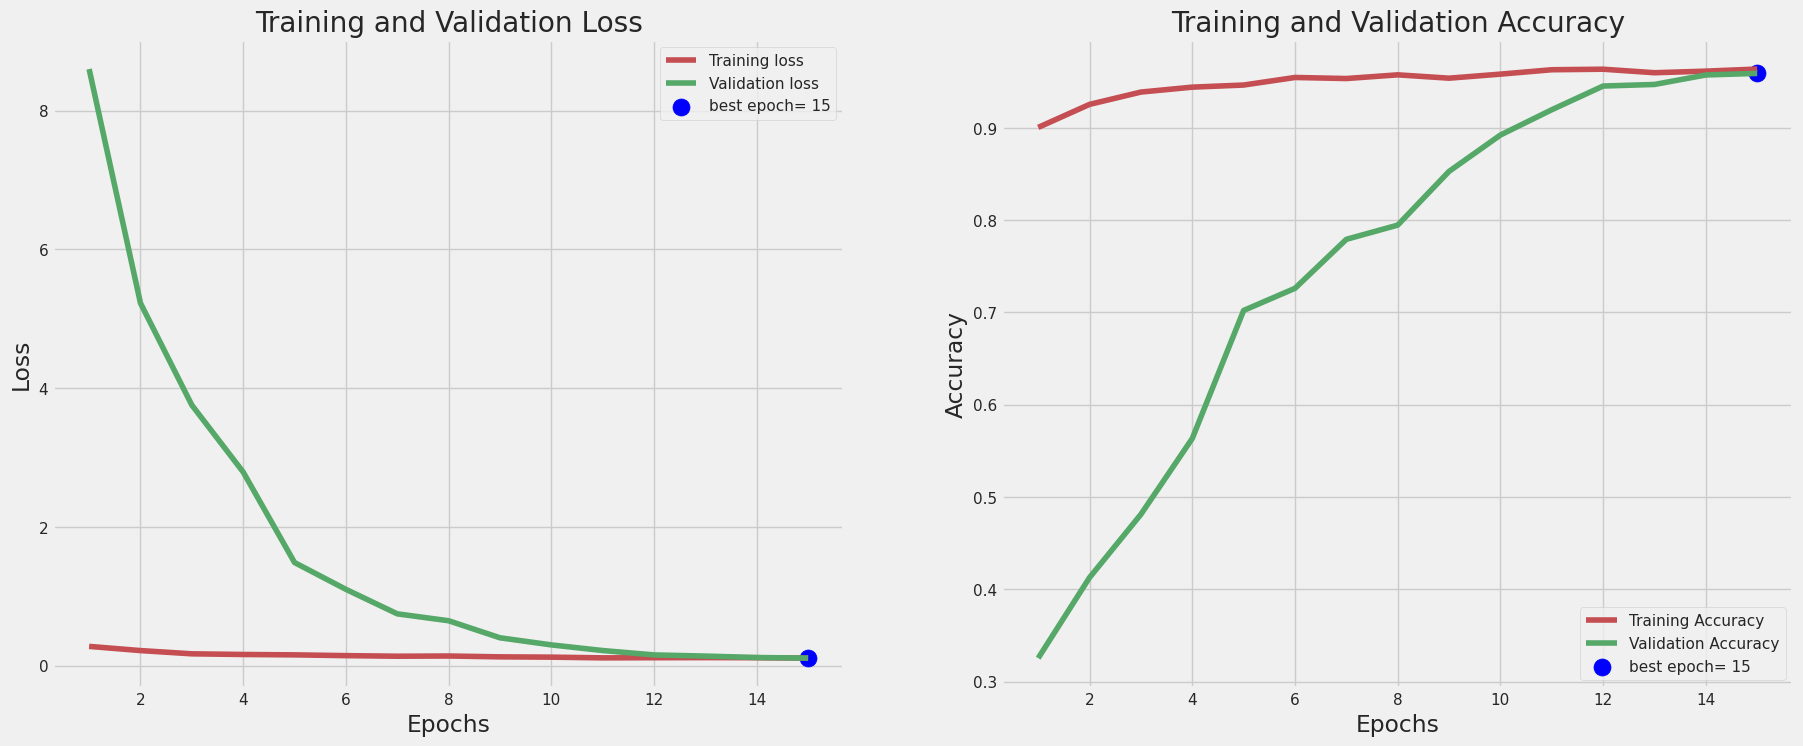

1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step - accuracy: 0.9508 - loss: 0.1339
Model accuracy on test set: 95.07692456245422 (0, 255, 0) (55, 65, 80)


In [ ]:
def tr_plot(tr_data, start_epoch):
    #Plot the training and validation data
    tacc=tr_data.history['accuracy']
    tloss=tr_data.history['loss']
    vacc=tr_data.history['val_accuracy']
    vloss=tr_data.history['val_loss']
    Epoch_count=len(tacc)+ start_epoch
    Epochs=[]
    for i in range (start_epoch ,Epoch_count):
        Epochs.append(i+1)
    index_loss=np.argmin(vloss)#  this is the epoch with the lowest validation loss
    val_lowest=vloss[index_loss]
    index_acc=np.argmax(vacc)
    acc_highest=vacc[index_acc]
    plt.style.use('fivethirtyeight')
    sc_label='best epoch= '+ str(index_loss+1 +start_epoch)
    vc_label='best epoch= '+ str(index_acc + 1+ start_epoch)
    fig,axes=plt.subplots(nrows=1, ncols=2, figsize=(20,8))
    axes[0].plot(Epochs,tloss, 'r', label='Training loss')
    axes[0].plot(Epochs,vloss,'g',label='Validation loss' )
    axes[0].scatter(index_loss+1 +start_epoch,val_lowest, s=150, c= 'blue', label=sc_label)
    axes[0].set_title('Training and Validation Loss')
    axes[0].set_xlabel('Epochs')
    axes[0].set_ylabel('Loss')
    axes[0].legend()
    axes[1].plot (Epochs,tacc,'r',label= 'Training Accuracy')
    axes[1].plot (Epochs,vacc,'g',label= 'Validation Accuracy')
    axes[1].scatter(index_acc+1 +start_epoch,acc_highest, s=150, c= 'blue', label=vc_label)
    axes[1].set_title('Training and Validation Accuracy')
    axes[1].set_xlabel('Epochs')
    axes[1].set_ylabel('Accuracy')
    axes[1].legend()
    plt.tight_layout
    #plt.style.use('fivethirtyeight')
    plt.show()


tr_plot(history, 0)
acc=model.evaluate(test_gen,batch_size=32, steps=None, verbose=1)[1]*100
msg='Model accuracy on test set: ' + str(acc)
print(msg, (0,255,0), (55,65,80))

In [ ]:
from sklearn.metrics import confusion_matrix


for X_batch, y_batch in test_gen:
    y_test = y_batch
    X_test = X_batch
    break

print('test label shape',y_test.shape)
print('test image shape',X_test.shape)
print('Evaluate on test-data:')
model.evaluate(X_test,y_test)

pred = model.predict(X_test)

bin_predict = np.argmax(pred,axis=1)
y_test = np.argmax(y_test,axis=1)


#Confusion matrix:
matrix = confusion_matrix(y_test, bin_predict)
print('Confusion Matrix:\n',matrix)

test label shape (325, 4)
test image shape (325, 224, 224, 3)
Evaluate on test-data:
11/11 ━━━━━━━━━━━━━━━━━━━━ 18s 2s/step - accuracy: 0.9506 - loss: 0.1068
11/11 ━━━━━━━━━━━━━━━━━━━━ 13s 614ms/step
Confusion Matrix:
 [[111   0   0   0]
 [  0  93   0   0]
 [  1   0  77   0]
 [ 14   0   1  28]]


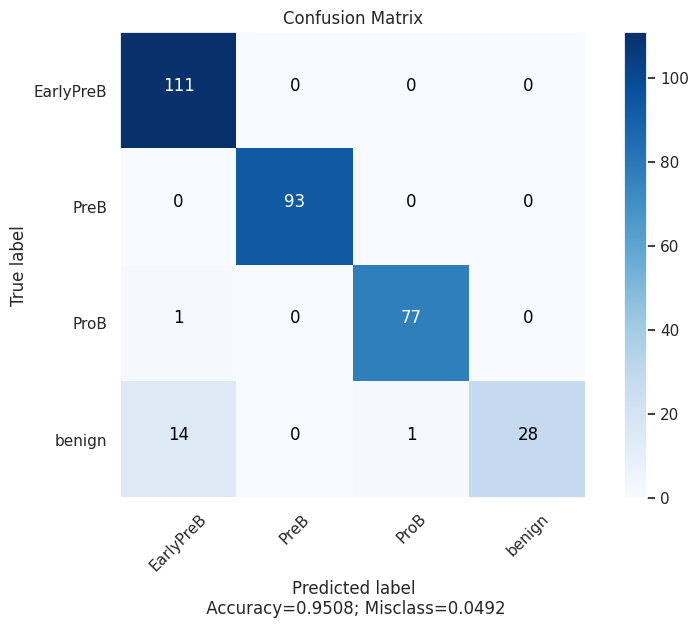

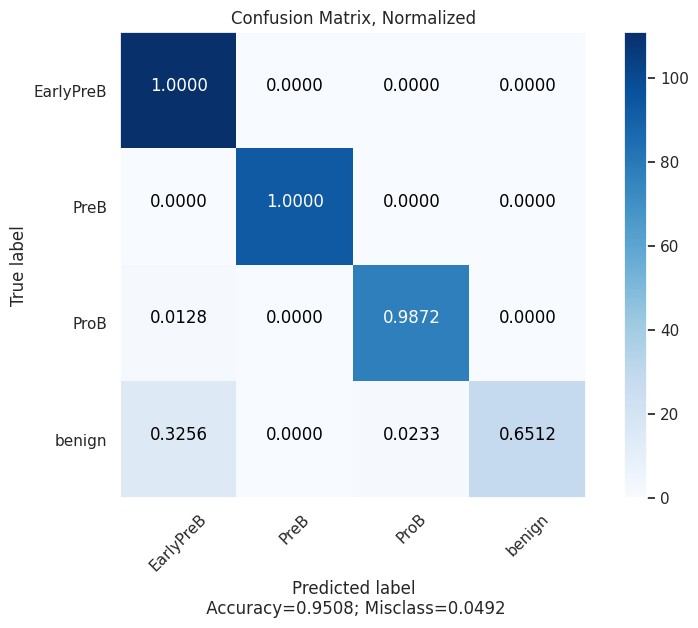

In [ ]:
import itertools

#Plot the Confusion matrix:
def plot_confusion_matrix(cm,
                          target_names,
                          title='Confusion matrix',
                          cmap=None,
                          normalize=True):

    accuracy = np.trace(cm) / float(np.sum(cm))
    misclass = 1 - accuracy
    sns.set(style="dark")
    if cmap is None:
        cmap = plt.get_cmap('Blues')

    plt.figure(figsize=(8, 6))
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()

    if target_names is not None:
        tick_marks = np.arange(len(target_names))
        plt.xticks(tick_marks, target_names, rotation=45)
        plt.yticks(tick_marks, target_names)

    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]


    thresh = cm.max() / 1.5 if normalize else cm.max() / 2
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        if normalize:
            plt.text(j, i, "{:0.4f}".format(cm[i, j]),
                     horizontalalignment="center",
                     color="white" if cm[i, j] > thresh else "black")
        else:
            plt.text(j, i, "{:,}".format(cm[i, j]),
                     horizontalalignment="center",
                     color="white" if cm[i, j] > thresh else "black")


    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label\n Accuracy={:0.4f}; Misclass={:0.4f}'.format(accuracy, misclass))
    plt.show()


plot_confusion_matrix(cm           = np.array(matrix),
                      normalize    = False,
                      target_names = ['EarlyPreB','PreB','ProB','benign'],
                      title        = "Confusion Matrix")

plot_confusion_matrix(cm           = np.array(matrix),
                      normalize    = True,
                      target_names = ['EarlyPreB','PreB','ProB','benign'],
                      title        = "Confusion Matrix, Normalized")

11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
Shape of preds:  (325, 4)


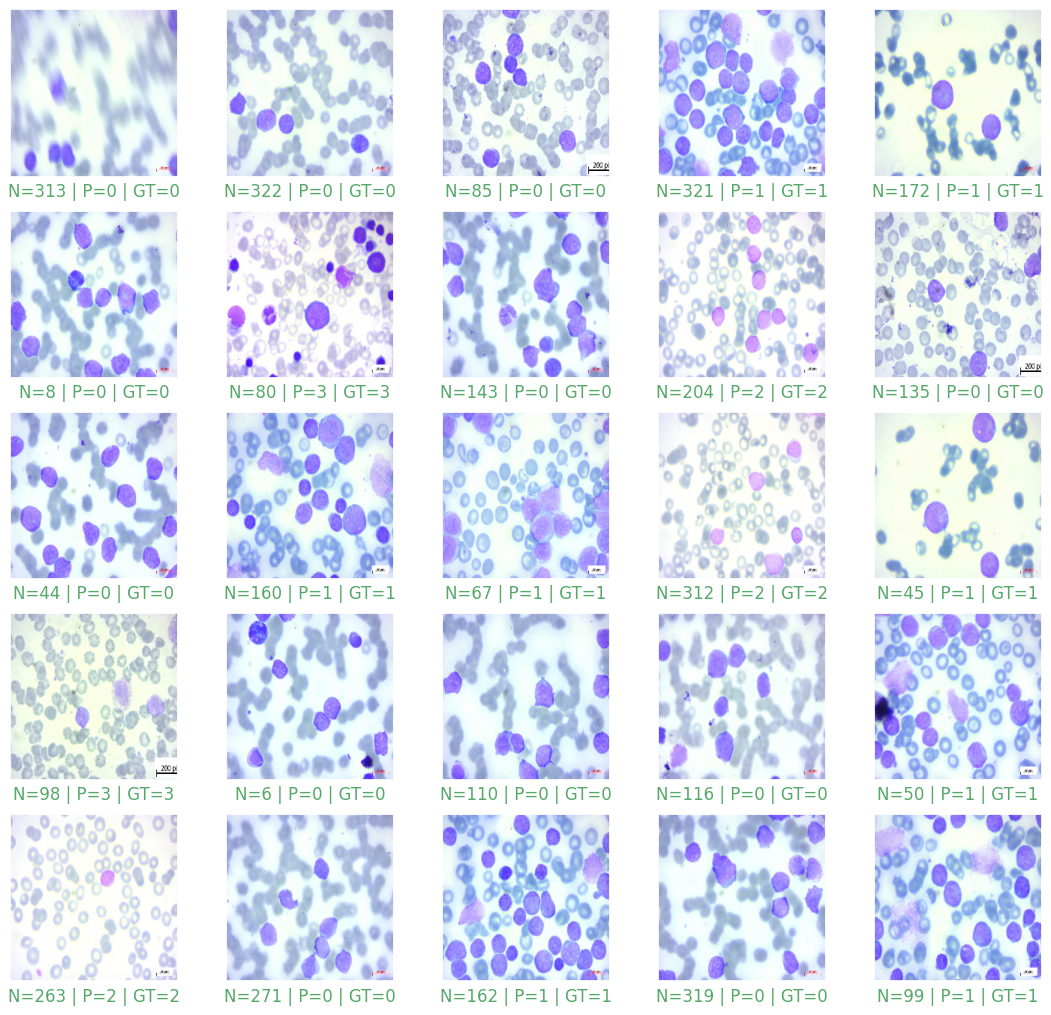

In [ ]:
preds = model.predict(X_test)
#print(preds)
print('Shape of preds: ', preds.shape)
plt.figure(figsize = (12, 12))

number = np.random.choice(preds.shape[0])

for i in range(25):
    plt.subplot(5, 5, i + 1)
    plt.grid(False)
    plt.xticks([])
    plt.yticks([])
    number = np.random.choice(preds.shape[0])
    pred = np.argmax(preds[number])
    actual = (y_test[number])
    col = 'g'
    if pred != actual:
        col = 'r'
    plt.xlabel('N={} | P={} | GT={}'.format(number, pred, actual), color = col) #N= number P= prediction GT= actual (ground truth)
    image= X_test[number]#cv2.cvtColor(X_test[number], cv2.COLOR_BGR2RGB)
    plt.imshow(((image* 255).astype(np.uint8)), cmap='binary')
plt.show()

In [ ]:
from scipy.optimize import minimize

# Validation logits & labels
val_logits = model.predict(valid_gen, steps=len(valid_gen), verbose=1)
val_labels = valid_gen.classes  # already class indices


19/19 ━━━━━━━━━━━━━━━━━━━━ 14s 298ms/step


In [ ]:
def softmax_with_temp(logits, T):
    logits = tf.convert_to_tensor(logits, dtype=tf.float32)
    scaled_logits = logits / T
    return tf.nn.softmax(scaled_logits, axis=1).numpy()

def nll_loss(T):
    probs = softmax_with_temp(val_logits, T)
    correct_class_probs = probs[np.arange(len(val_labels)), val_labels]
    return -np.mean(np.log(correct_class_probs + 1e-12))


In [ ]:
res = minimize(lambda T: nll_loss(T[0]), x0=[1.0], bounds=[(0.5, 3)])
T_opt = res.x[0]
print("✅ Optimal Temperature:", T_opt)


✅ Optimal Temperature: 1.0


In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing import image

# --- Function to preprocess a single image ---
def preprocess_image(img_path, target_size=(224, 224)):
    img = image.load_img(img_path, target_size=target_size)   # Resize to model input
    img_array = image.img_to_array(img) / 255.0              # Normalize [0,1]
    img_array = np.expand_dims(img_array, axis=0)            # Add batch dimension
    return img_array

# --- Function to predict with confidence estimation ---
def predict_with_confidence(img_path, model, T_opt, class_names):
    # Preprocess
    img_array = preprocess_image(img_path)

    # Get logits (raw outputs)
    logits = model(img_array, training=False).numpy()

    # Apply temperature scaling
    scaled_logits = logits / T_opt
    probs = tf.nn.softmax(scaled_logits, axis=1).numpy()[0]

    # Get top prediction
    predicted_class = np.argmax(probs)
    confidence = probs[predicted_class]

    print(f"Predicted Class: {class_names[predicted_class]}")
    print(f"Confidence: {confidence:.4f}")
    print(f"Calibrated Probabilities: {probs}")
    return predicted_class, confidence, probs

# Example usage:
# Replace with your actual class names (order should match your model output)
class_names = ["Benign", "Pre", "Pro", "Early"]

# Test with one image
img_path = "/content/drive/MyDrive/ Acute Lymphoblastic Leukemia/Blood cell Cancer [ALL]/[Malignant] Pro-B/Snap_012.jpg"  # <-- put your image path here
predict_with_confidence(img_path, model, T_opt, class_names)

Predicted Class: Pro
Confidence: 0.4754
Calibrated Probabilities: [0.17487781 0.17487781 0.47536621 0.17487817]


(np.int64(2),
 np.float64(0.47536620863962087),
 array([0.17487781, 0.17487781, 0.47536621, 0.17487817]))

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing import image

# --- Function to preprocess a single image ---
def preprocess_image(img_path, target_size=(224, 224)):
    img = image.load_img(img_path, target_size=target_size)   # Resize to model input
    img_array = image.img_to_array(img) / 255.0              # Normalize [0,1]
    img_array = np.expand_dims(img_array, axis=0)            # Add batch dimension
    return img_array

# --- Function to predict with confidence estimation ---
def predict_with_confidence(img_path, model, T_opt, class_names):
    # Preprocess
    img_array = preprocess_image(img_path)

    # Get logits (raw outputs)
    logits = model(img_array, training=False).numpy()

    # Apply temperature scaling
    scaled_logits = logits / T_opt
    probs = tf.nn.softmax(scaled_logits, axis=1).numpy()[0]

    # Get top prediction
    predicted_class = np.argmax(probs)
    confidence = probs[predicted_class]

    print(f"Predicted Class: {class_names[predicted_class]}")
    print(f"Confidence: {confidence:.4f}")
    print(f"Calibrated Probabilities: {probs}")
    return predicted_class, confidence, probs

# Example usage:
# Replace with your actual class names (order should match your model output)
class_names = ["Benign", "Pre", "Pro", "Early"]

# Test with one image
img_path = "/content/drive/MyDrive/ Acute Lymphoblastic Leukemia/Blood cell Cancer [ALL]/[Malignant] early Pre-B/Sap_148 (100).jpg"  # <-- put your image path here
predict_with_confidence(img_path, model, T_opt, class_names)

Predicted Class: Benign
Confidence: 0.4754
Calibrated Probabilities: [0.47536688 0.17487771 0.1748777  0.1748777 ]


(np.int64(0),
 np.float64(0.4753668838693993),
 array([0.47536688, 0.17487771, 0.1748777 , 0.1748777 ]))

In [ ]:
# Save model to H5
model.save("all_model_calibrated.h5")
print("✅ Model saved as all_model_calibrated.h5")


✅ Model saved as all_model_calibrated.h5
